# Fase 3: calibracion lateral con MultiPosture

El dataset lateral visual `sitting_posture_4keypoint` sirve para validar que YOLO detecta keypoints en perfil,
pero sus etiquetas `Good` y `Bad` no son suficientemente fiables como patron ergonomico.

Para calibrar reglas laterales usamos MultiPosture:
- 4.794 frames de postura sentada
- keypoints 3D ya extraidos
- etiquetas de tronco validadas por expertos
- no contiene imagenes por privacidad, asi que no sirve para benchmark visual de YOLO

Etiquetas de tronco:
- `TUP`: tronco erguido
- `TLF`: tronco inclinado hacia delante
- `TLB`: tronco inclinado hacia atras
- `TLR`: tronco inclinado a la derecha
- `TLL`: tronco inclinado a la izquierda

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate
    return current


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.max_columns = 80
pd.options.display.float_format = "{:,.3f}".format

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"SRC_DIR: {SRC_DIR}")

PROJECT_ROOT: /home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I
SRC_DIR: /home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I/src


In [2]:
from ergonomics import (
    MULTIPOSTURE_CSV_PATH,
    UPPERBODY_LABELS,
    build_multiposture_metric_dataframe,
    load_multiposture_dataframe,
    summarize_multiposture_metrics,
)

## 1. Carga del dataset

In [3]:
raw_df = load_multiposture_dataframe(MULTIPOSTURE_CSV_PATH)
metric_df = build_multiposture_metric_dataframe(raw_df)

display(
    pd.DataFrame(
        [
            {"item": "CSV", "value": str(MULTIPOSTURE_CSV_PATH)},
            {"item": "Filas", "value": len(raw_df)},
            {"item": "Sujetos", "value": raw_df["subject"].nunique()},
            {"item": "Etiquetas tronco", "value": ", ".join(sorted(raw_df["upperbody_label"].unique()))},
        ]
    )
)

display(raw_df[["subject", "upperbody_label", "lowerbody_label"]].head())
display(raw_df["upperbody_label"].value_counts().rename_axis("upperbody_label").reset_index(name="frame_count"))

,item,value
0,CSV,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...
1,Filas,4794
2,Sujetos,13
3,Etiquetas tronco,"TLB, TLF, TLL, TLR, TUP"


,subject,upperbody_label,lowerbody_label
0,1,TLB,LCL
1,1,TLB,LCL
2,1,TLB,LCL
3,1,TLB,LCL
4,1,TLB,LCL


,upperbody_label,frame_count
0,TLF,1897
1,TUP,1615
2,TLB,442
3,TLL,420
4,TLR,420


## 2. Variables 3D para calibracion

Calculamos medidas equivalentes a las reglas laterales, pero usando coordenadas 3D:
- inclinacion sagital del tronco
- inclinacion lateral del tronco
- desplazamiento profundidad hombro-cadera
- desplazamiento profundidad cabeza-hombros
- inclinacion sagital cuello-hombros

In [4]:
display(metric_df.head())

summary_df = summarize_multiposture_metrics(metric_df)
display(summary_df)

,subject,upperbody_label,upperbody_label_name,lowerbody_label,torso_length_3d,trunk_forward_tilt_3d_deg,trunk_lateral_tilt_3d_deg,shoulder_hip_depth_offset_ratio,head_forward_offset_3d_ratio,neck_forward_tilt_3d_deg
0,1,TLB,trunk_leaning_backward,LCL,0.427,10.525,0.632,0.183,0.600,65.994
1,1,TLB,trunk_leaning_backward,LCL,0.409,10.154,3.723,0.176,0.756,72.714
2,1,TLB,trunk_leaning_backward,LCL,0.424,10.536,2.973,0.183,0.716,67.557
3,1,TLB,trunk_leaning_backward,LCL,0.441,17.360,2.702,0.298,0.643,64.607
4,1,TLB,trunk_leaning_backward,LCL,0.439,14.878,2.524,0.257,0.661,65.535


,upperbody_label,upperbody_label_name,metric,count,mean,q10,q25,q50,q75,q90
0,TLB,trunk_leaning_backward,head_forward_offset_3d_ratio,442,0.581,0.476,0.523,0.582,0.630,0.674
1,TLF,trunk_leaning_forward,head_forward_offset_3d_ratio,1897,0.684,0.601,0.628,0.667,0.721,0.800
2,TLL,trunk_leaning_left,head_forward_offset_3d_ratio,420,0.570,0.485,0.527,0.568,0.620,0.657
3,TLR,trunk_leaning_right,head_forward_offset_3d_ratio,420,0.571,0.480,0.539,0.576,0.605,0.646
4,TUP,upright_trunk,head_forward_offset_3d_ratio,1615,0.653,0.578,0.605,0.641,0.697,0.754
5,TLB,trunk_leaning_backward,neck_forward_tilt_3d_deg,442,67.226,57.951,61.535,67.234,73.130,75.737
6,TLF,trunk_leaning_forward,neck_forward_tilt_3d_deg,1897,74.117,65.088,68.848,73.573,79.433,84.575
7,TLL,trunk_leaning_left,neck_forward_tilt_3d_deg,420,75.239,64.835,71.253,76.237,78.932,82.884
8,TLR,trunk_leaning_right,neck_forward_tilt_3d_deg,420,77.492,69.340,71.917,77.177,82.719,87.410
9,TUP,upright_trunk,neck_forward_tilt_3d_deg,1615,70.653,64.106,66.757,70.260,74.310,78.350


## 3. Lectura de separacion entre etiquetas expertas

La etiqueta `TUP` se usa como referencia de tronco erguido.
Las etiquetas `TLF`, `TLB`, `TLR` y `TLL` sirven para estimar rangos de desviacion.

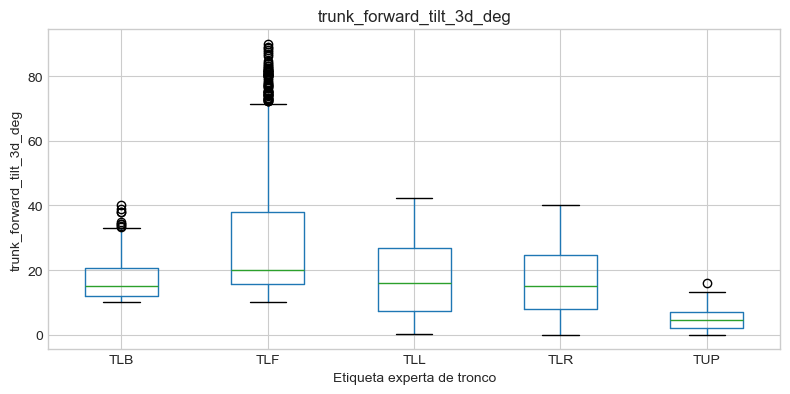

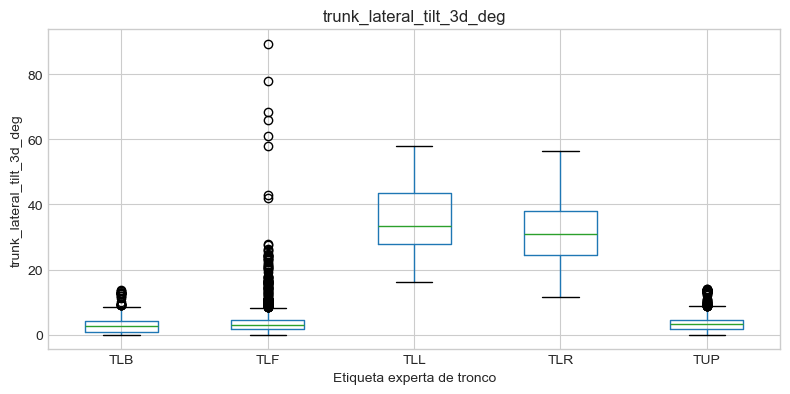

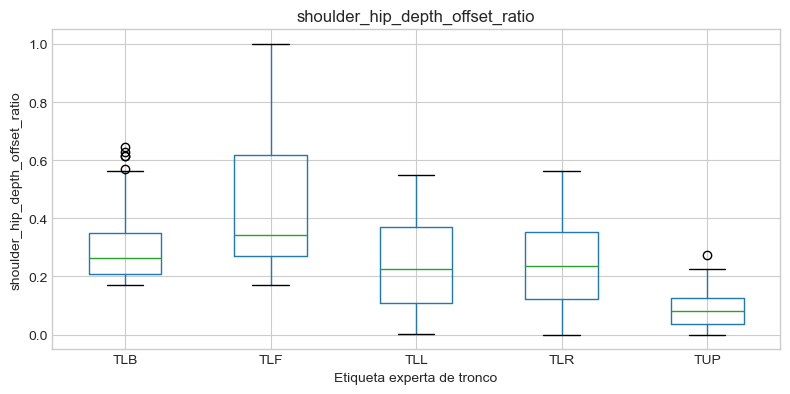

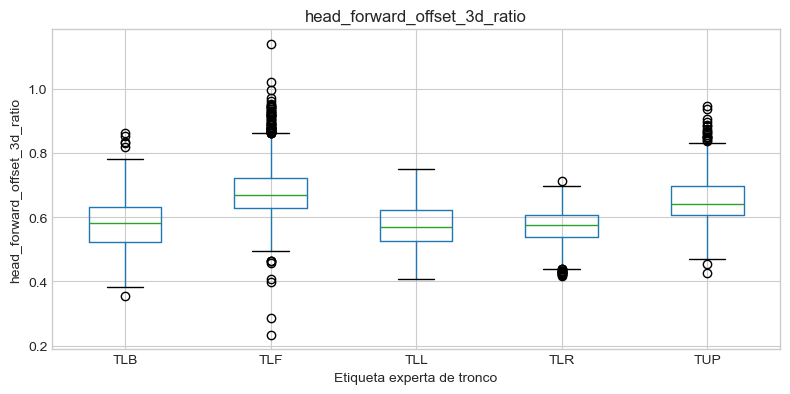

In [5]:
metrics_to_plot = [
    "trunk_forward_tilt_3d_deg",
    "trunk_lateral_tilt_3d_deg",
    "shoulder_hip_depth_offset_ratio",
    "head_forward_offset_3d_ratio",
]

for metric in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(8, 4.2))
    metric_df.boxplot(column=metric, by="upperbody_label", ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("Etiqueta experta de tronco")
    ax.set_ylabel(metric)
    fig.suptitle("")
    plt.tight_layout()
    plt.show()

## 4. Candidatos de umbral para reglas laterales

Estos candidatos no sustituyen la auditoria visual, pero dan un suelo mas fiable que las etiquetas `Good/Bad`
del dataset lateral visual.

Lectura propuesta:
- para tronco sagital, `TUP` tiene q75 cercano a 7 grados y q90 cercano a 9 grados
- para inclinacion lateral, `TUP` tiene q75 cercano a 4.5 grados y q90 cercano a 6.4 grados
- `TLF` confirma que valores sagitales altos representan flexion clara hacia delante

In [6]:
tup_df = metric_df[metric_df["upperbody_label"] == "TUP"]
threshold_candidates = pd.DataFrame(
    [
        {
            "metric": "trunk_forward_tilt_deg",
            "current_source": "MultiPosture TUP",
            "candidate_adequate_max": tup_df["trunk_forward_tilt_3d_deg"].quantile(0.75),
            "candidate_improvable_max": tup_df["trunk_forward_tilt_3d_deg"].quantile(0.90),
            "comment": "Referencia directa para tronco erguido en plano sagital.",
        },
        {
            "metric": "trunk_lateral_tilt_deg",
            "current_source": "MultiPosture TUP",
            "candidate_adequate_max": tup_df["trunk_lateral_tilt_3d_deg"].quantile(0.75),
            "candidate_improvable_max": tup_df["trunk_lateral_tilt_3d_deg"].quantile(0.90),
            "comment": "Referencia para evitar confundir postura erguida con inclinacion lateral.",
        },
        {
            "metric": "shoulder_hip_depth_offset_ratio",
            "current_source": "MultiPosture TUP",
            "candidate_adequate_max": tup_df["shoulder_hip_depth_offset_ratio"].quantile(0.75),
            "candidate_improvable_max": tup_df["shoulder_hip_depth_offset_ratio"].quantile(0.90),
            "comment": "Equivalente 3D del offset hombro-cadera lateral.",
        },
    ]
)

display(threshold_candidates)

,metric,current_source,candidate_adequate_max,candidate_improvable_max,comment
0,trunk_forward_tilt_deg,MultiPosture TUP,7.163,8.664,Referencia directa para tronco erguido en plan...
1,trunk_lateral_tilt_deg,MultiPosture TUP,4.549,6.355,Referencia para evitar confundir postura ergui...
2,shoulder_hip_depth_offset_ratio,MultiPosture TUP,0.124,0.150,Equivalente 3D del offset hombro-cadera lateral.


## 5. Conclusion operativa

MultiPosture debe usarse para calibrar reglas de tronco, no para validar YOLO.
El dataset visual lateral debe seguir usandose para probar deteccion y revisar casos.

Siguiente paso recomendado:
- ajustar las reglas laterales de tronco usando los candidatos de `TUP`
- mantener cabeza/cuello como regla provisional hasta conseguir imagenes laterales etiquetadas con criterio ergonomico
- crear una auditoria lateral visual para documentar que `Good/Bad` del dataset visual no equivale a `adequate/risk` ROSA

## 6. Resultado tras aplicar la calibracion

Con estos umbrales, el analisis lateral visual deja de saturarse en `risk`.
La lectura esperada de la corrida `sitting_posture_4keypoint_yolo_lateral_full_dataset` es:

- `Bad`: alrededor de 62% `risk`
- `Good`: alrededor de 29% `risk` y 43% `adequate`

Esto no significa que `Good` sea automaticamente correcto segun ROSA. Significa que las reglas de tronco ya
separan mejor entre grupos sin obligarse a aceptar todas las etiquetas originales del dataset visual.